In [1]:
from datasets import load_dataset, concatenate_datasets

ds = load_dataset("liamdugan/raid")

full_dataset = concatenate_datasets([ds["train"], ds["extra"]])
df = full_dataset.to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/11.8G [00:00<?, ?B/s]

extra.csv:   0%|          | 0.00/3.71G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating extra split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]

In [2]:
df.columns

Index(['id', 'adv_source_id', 'source_id', 'model', 'decoding',
       'repetition_penalty', 'attack', 'domain', 'title', 'prompt',
       'generation'],
      dtype='object')

In [4]:
df.head(1)

,id,adv_source_id,source_id,model,decoding,repetition_penalty,attack,domain,title,prompt,generation
0,e5e058ce-be2b-459d-af36-32532aaba5ff,e5e058ce-be2b-459d-af36-32532aaba5ff,e5e058ce-be2b-459d-af36-32532aaba5ff,human,None,None,none,abstracts,FUTURE-AI: Guiding Principles and Consensus Re...,None,The recent advancements in artificial intellig...


In [7]:
raid = df[['model', 'generation']].copy()
raid.head()

,model,generation
0,human,The recent advancements in artificial intellig...
1,human,High-quality training data play a key role in ...
2,human,The success of deep learning methods in medica...
3,human,Simultaneous segmentation of multiple organs f...
4,human,Detection faults in seismic data is a crucial ...


In [17]:
raid['model_type'] = raid['model'].apply(lambda x: 'human' if x == 'human' else 'LLM')
print(raid['model_type'].value_counts())

model_type
LLM      7436208
human     218712
Name: count, dtype: int64


Now, let's see the median and standard deviation of generation lengths grouped by this new `model_type` column.

In [18]:
model_stats_by_type = raid.groupby('model_type')['generation_length'].agg(['median', 'std']).reset_index()
print(model_stats_by_type.to_markdown(index=False))

| model_type   |   median |      std |
|:-------------|---------:|---------:|
| LLM          |     1348 |  816.457 |
| human        |     1365 | 1933.98  |


/tmp/ipykernel_656/3294114875.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Model')
/tmp/ipykernel_656/3294114875.py:13: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


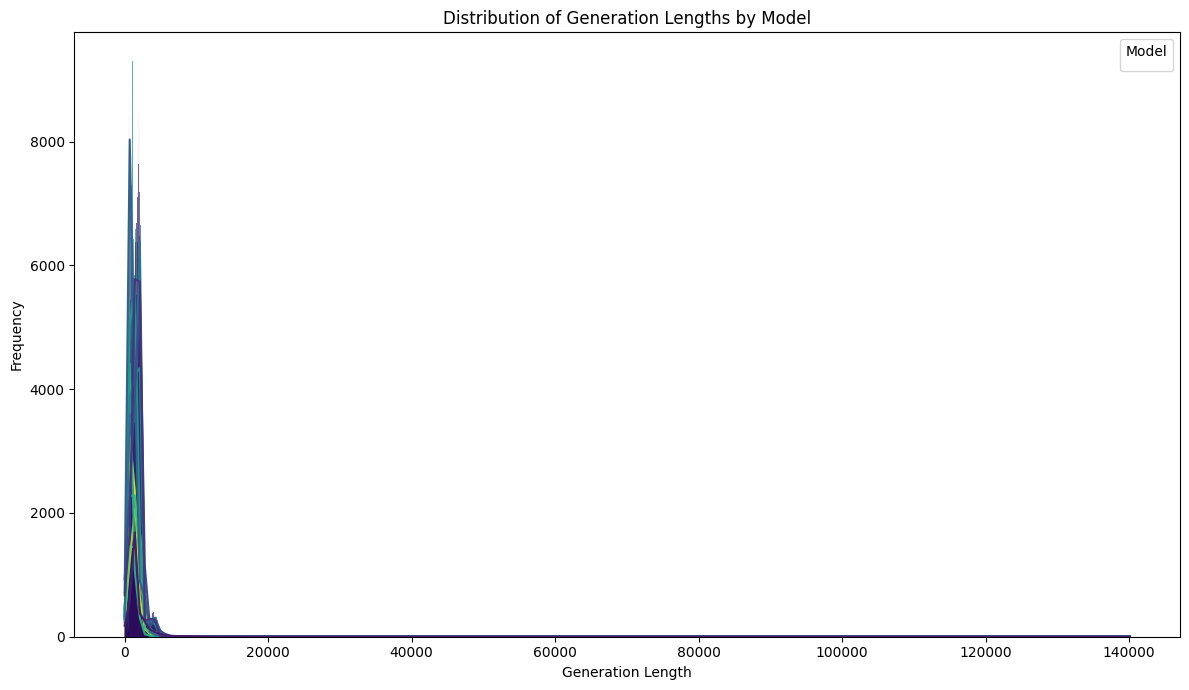

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the length of each generation
raid['generation_length'] = raid['generation'].apply(len)

plt.figure(figsize=(12, 7))
sns.histplot(data=raid, x='generation_length', hue='model', kde=True, palette='viridis', alpha=0.7)
plt.title('Distribution of Generation Lengths by Model')
plt.xlabel('Generation Length')
plt.ylabel('Frequency')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

In [11]:
print(raid['model'].value_counts())

model
llama-chat      874848
mpt             874848
mpt-chat        874848
gpt2            874848
mistral-chat    874848
mistral         874848
cohere          437424
gpt3            437424
gpt4            437424
chatgpt         437424
cohere-chat     437424
human           218712
Name: count, dtype: int64


If there's more than one unique 'model', the `hue` parameter in `histplot` should automatically create a legend. Let's replot with a slight adjustment to explicitly manage the legend if needed, and to demonstrate how you can change plotting parameters.

/tmp/ipykernel_656/1611562360.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


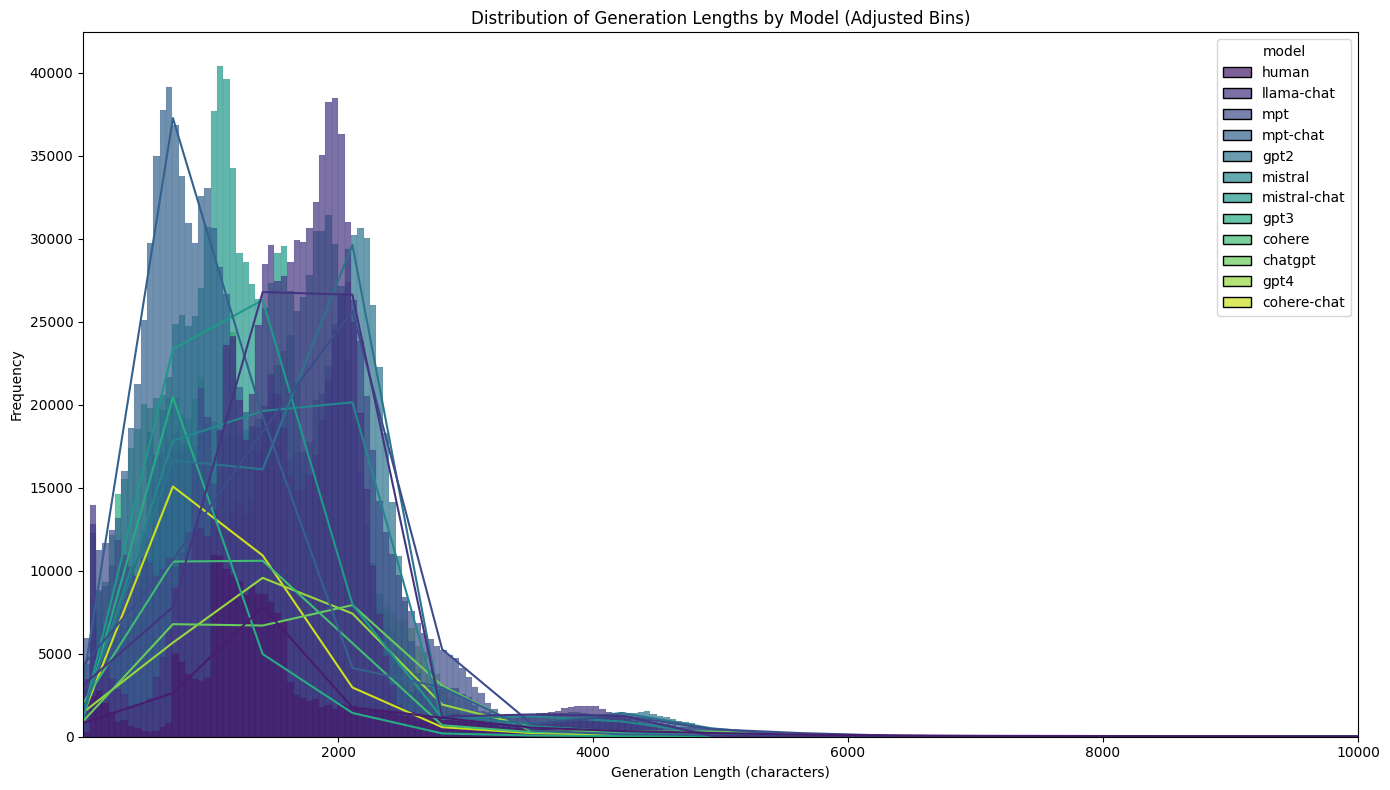

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
# Using 'binwidth' for more control, or 'bins' for number of bins
sns.histplot(data=raid, x='generation_length', hue='model', kde=True, palette='viridis', alpha=0.7,
             binwidth=50) # Example: set binwidth to 50 characters
plt.title('Distribution of Generation Lengths by Model (Adjusted Bins)')
plt.xlabel('Generation Length (characters)')
plt.ylabel('Frequency')

# Set x-axis limits
plt.xlim(1, 10000)

# When using `hue` in seaborn, the legend is typically generated automatically.
# If `model` has more than one unique value, the legend will appear.
# No explicit `plt.legend()` call is needed here, as `sns.histplot` handles it.

plt.tight_layout()
plt.show()

In [14]:
model_stats = raid.groupby('model')['generation_length'].agg(['median', 'std']).reset_index()
print(model_stats.to_markdown(index=False))

| model        |   median |      std |
|:-------------|---------:|---------:|
| chatgpt      |     1560 |  892.599 |
| cohere       |     1276 |  796.196 |
| cohere-chat  |     1042 |  677.025 |
| gpt2         |     1681 |  855.827 |
| gpt3         |      731 |  522.837 |
| gpt4         |     1656 |  814.575 |
| human        |     1365 | 1933.98  |
| llama-chat   |     1660 |  722.903 |
| mistral      |     1546 |  766.561 |
| mistral-chat |     1185 |  627.55  |
| mpt          |     1618 |  954.026 |
| mpt-chat     |      940 |  721.192 |


In [20]:
import numpy as np
raid['model_group'] = np.where(raid['model'].str.lower().eq('human'), 'human', 'llm')

model_stats = (
    raid.groupby('model_group')['generation_length']
    .agg(['median', 'std'])
    .reset_index()
)

print(model_stats.to_markdown(index=False))

| model_group   |   median |      std |
|:--------------|---------:|---------:|
| human         |     1365 | 1933.98  |
| llm           |     1348 |  816.457 |
